In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

**Loading the dataset into Colab files**

In [ ]:
zip_path = "/content/internet+advertisements.zip"
assert os.path.exists(zip_path), "Zip file not found in /content. Please upload 'internet+advertisements.zip'."

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/internet_ads")

data_dir = "/content/internet_ads"
files = os.listdir(data_dir)
files



['ad.data', 'ad.names', 'ad.DOCUMENTATION']

In [ ]:
names_path = os.path.join(data_dir, "ad.names")
doc_path = os.path.join(data_dir, "ad.DOCUMENTATION")
data_path = os.path.join(data_dir, "ad.data")

with open(names_path, 'r', encoding='latin-1') as f:
    names_text = f.read()

num_features = 1558
feature_names = [f"feat_{i}" for i in range(num_features)]
columns = feature_names + ["Class"]

df = pd.read_csv(
    data_path,
    header=None,
    names=columns,
    na_values=["?"],
    sep=",",
    engine="python"
)

print(df.head())


  feat_0 feat_1  feat_2  feat_3  feat_4  feat_5  feat_6  feat_7  feat_8  \
0    125    125     1.0     1.0       0       0       0       0       0   
1     57    468  8.2105     1.0       0       0       0       0       0   
2     33    230  6.9696     1.0       0       0       0       0       0   
3     60    468     7.8     1.0       0       0       0       0       0   
4     60    468     7.8     1.0       0       0       0       0       0   

   feat_9  ...  feat_1549  feat_1550  feat_1551  feat_1552  feat_1553  \
0       0  ...          0          0          0          0          0   
1       0  ...          0          0          0          0          0   
2       0  ...          0          0          0          0          0   
3       0  ...          0          0          0          0          0   
4       0  ...          0          0          0          0          0   

   feat_1554  feat_1555  feat_1556  feat_1557  Class  
0          0          0          0          0    ad.  


**Normalizing the labels and identifying numeric-like columns and printing the information**

In [ ]:
print("Shape:", df.shape)
print(df['Class'].value_counts(dropna=False))

df['Class'] = df['Class'].map({'ad.': 1, 'nonad.': 0})
print("Label distribution (0=nonad,1=ad):")
print(df['Class'].value_counts())

def coerce_numeric(series):
    return pd.to_numeric(series, errors='coerce')

numeric_df = df[feature_names].apply(coerce_numeric)
numeric_mask = numeric_df.notna().mean() > 0.5
numeric_cols = list(numeric_df.columns[numeric_mask])
binary_or_text_cols = list(set(feature_names) - set(numeric_cols))

print("Estimated numeric columns:", len(numeric_cols))
print("Estimated binary/text columns:", len(binary_or_text_cols))


Shape: (3279, 1559)
Class
nonad.    2820
ad.        459
Name: count, dtype: int64
Label distribution (0=nonad,1=ad):
Class
0    2820
1     459
Name: count, dtype: int64
Estimated numeric columns: 1558
Estimated binary/text columns: 0


**Data Cleaning**

In [ ]:
missing_rate = df[feature_names].isna().mean().sort_values(ascending=False)
high_missing_cols = list(missing_rate[missing_rate > 0.6].index)
print("High missing features removed:", len(high_missing_cols))

df_clean = df.drop(columns=high_missing_cols)
remaining_features = [c for c in df_clean.columns if c != "Class"]

numeric_df = df_clean[remaining_features].apply(coerce_numeric)
numeric_mask = numeric_df.notna().mean() > 0.5
numeric_cols = list(numeric_df.columns[numeric_mask])
binary_text_cols = list(set(remaining_features) - set(numeric_cols))

for c in numeric_cols:
    med = numeric_df[c].median()
    numeric_df[c] = numeric_df[c].fillna(med)

binary_df = df_clean[binary_text_cols].copy()
binary_df = binary_df.notna().astype(int)

X = pd.concat([numeric_df, binary_df], axis=1)
y = df_clean['Class'].copy()

print("Final feature count after cleaning:", X.shape[1])
X.head()


High missing features removed: 0
Final feature count after cleaning: 1558


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_1548,feat_1549,feat_1550,feat_1551,feat_1552,feat_1553,feat_1554,feat_1555,feat_1556,feat_1557
0,125.0,125.0,1.0000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,57.0,468.0,8.2105,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,33.0,230.0,6.9696,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,60.0,468.0,7.8000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,60.0,468.0,7.8000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X)
selected_low_variance = vt.get_support(indices=True)
X_vt_df = X.iloc[:, selected_low_variance]
print("Features after variance threshold:", X_vt_df.shape[1])

mi = mutual_info_classif(X_vt_df, y, discrete_features=[i >= len(numeric_cols) for i in range(X_vt_df.shape[1])], random_state=42)
mi_series = pd.Series(mi, index=X_vt_df.columns).sort_values(ascending=False)

top_k = 50
top_features = list(mi_series.head(top_k).index)
X_top = X_vt_df[top_features].copy()
print("Top features selected:", len(top_features))
mi_series.head(10)


Features after variance threshold: 209
Top features selected: 50


,0
feat_2,0.196767
feat_1,0.188471
feat_0,0.164698
feat_1243,0.108643
feat_351,0.088237
feat_1399,0.081199
feat_968,0.070406
feat_1344,0.062596
feat_1483,0.061634
feat_1455,0.057165


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.25, stratify=y, random_state=42)

numeric_selected = [c for c in top_features if c in numeric_cols]
scaler = StandardScaler()
if numeric_selected:
    X_train[numeric_selected] = scaler.fit_transform(X_train[numeric_selected])
    X_test[numeric_selected] = scaler.transform(X_test[numeric_selected])


**Box Plot for different attributes**

**Plot 1 :** Shows median and spread with some outliers.

**Plot 2 :** Distribution is tighter with fewer extreme values.

**Plot 3 :** Wider spread indicates higher variability.

**Plot 4 :** Mostly consistent values with few deviations.

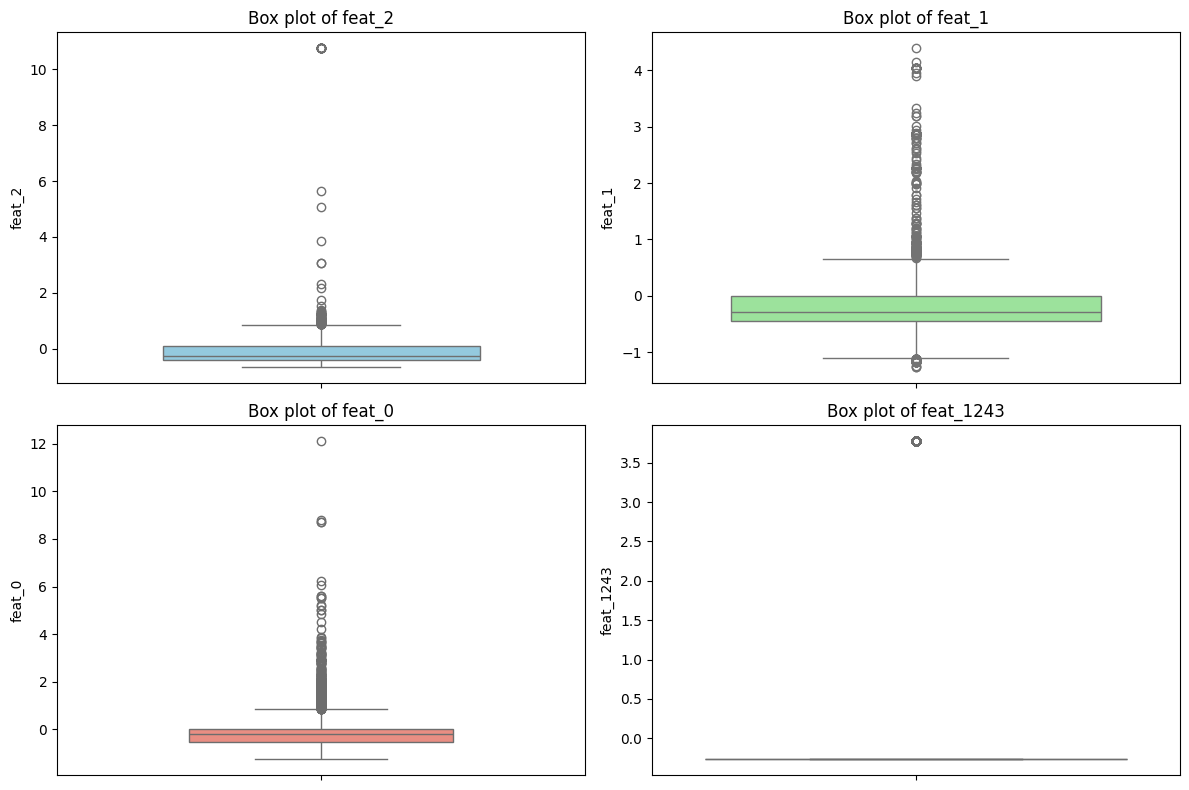

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.boxplot(y=X_train[top_features[0]], width=0.6, ax=axes[0,0], color="skyblue")
axes[0,0].set_title(f"Box plot of {top_features[0]}")

sns.boxplot(y=X_train[top_features[1]], width=0.7, ax=axes[0,1], color="lightgreen")
axes[0,1].set_title(f"Box plot of {top_features[1]}")

sns.boxplot(y=X_train[top_features[2]], width=0.5, ax=axes[1,0], color="salmon")
axes[1,0].set_title(f"Box plot of {top_features[2]}")

sns.boxplot(y=X_train[top_features[3]], width=0.8, ax=axes[1,1], color="violet")
axes[1,1].set_title(f"Box plot of {top_features[3]}")

plt.tight_layout()
plt.show()


**Histogram for different attributes**

**Plot 1 :** Histogram shows skew with a few high values dominating.

**Plot 2 :** Distribution is fairly balanced with moderate spread.

**Plot 3 :** Wide spread indicates variability across samples.

**Plot 4 :** Concentrated around lower values, suggesting less variation.

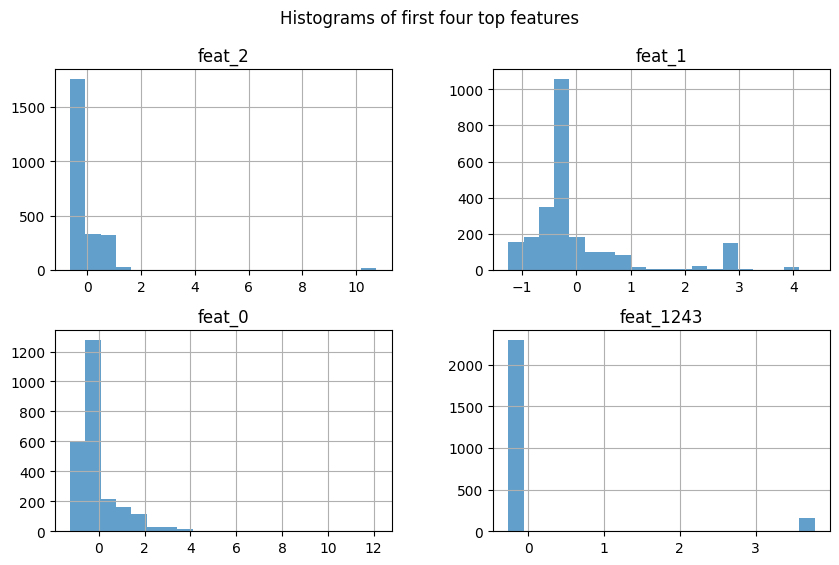

In [ ]:
X_train[top_features[:4]].hist(bins=20, figsize=(10,6), alpha=0.7)
plt.suptitle("Histograms of first four top features")
plt.show()


**Correlation Heatmap**


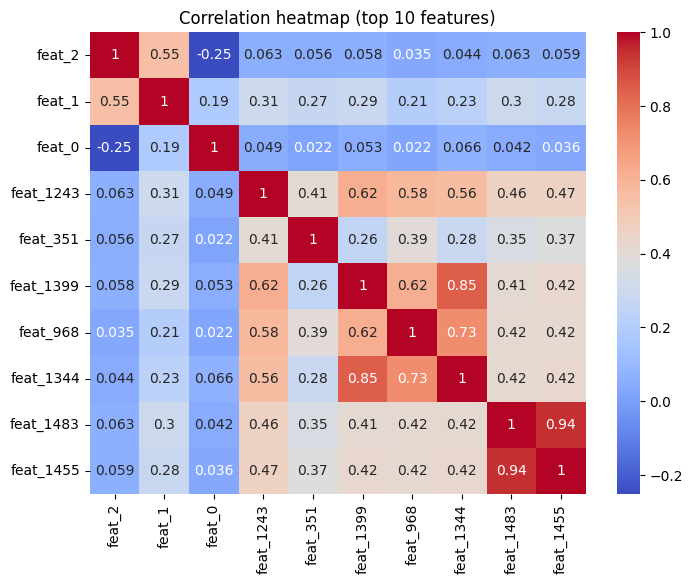

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(X_train[top_features[:10]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation heatmap (top 10 features)")
plt.show()


**Scatter Plot**


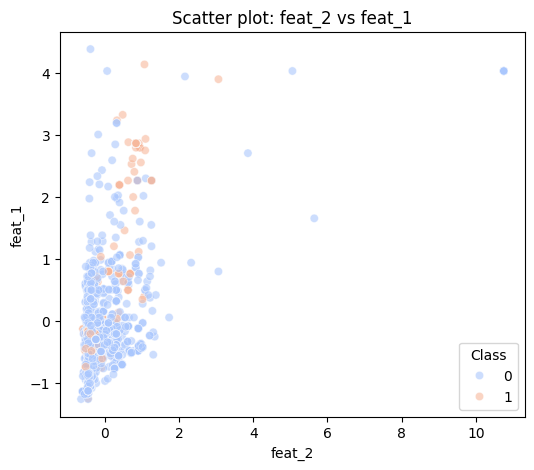

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=X_train[top_features[0]], y=X_train[top_features[1]], hue=y_train, palette="coolwarm", alpha=0.6)
plt.title(f"Scatter plot: {top_features[0]} vs {top_features[1]}")
plt.show()


**Violin Plot**

Distribution differs between classes, showing discriminative potential.


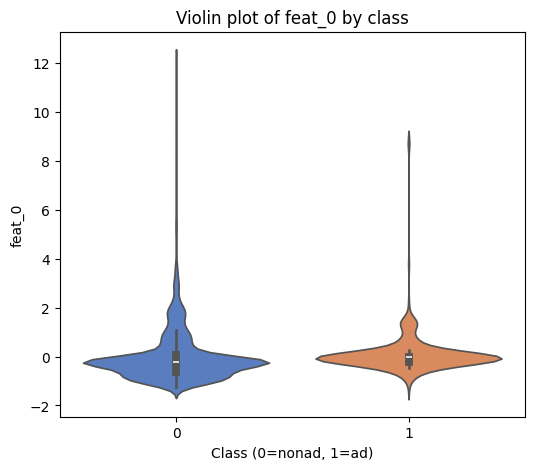

In [ ]:
plt.figure(figsize=(6,5))
sns.violinplot(x=y_train, y=X_train[top_features[2]], palette="muted")
plt.title(f"Violin plot of {top_features[2]} by class")
plt.xlabel("Class (0=nonad, 1=ad)")
plt.show()


**Pareto Chart**

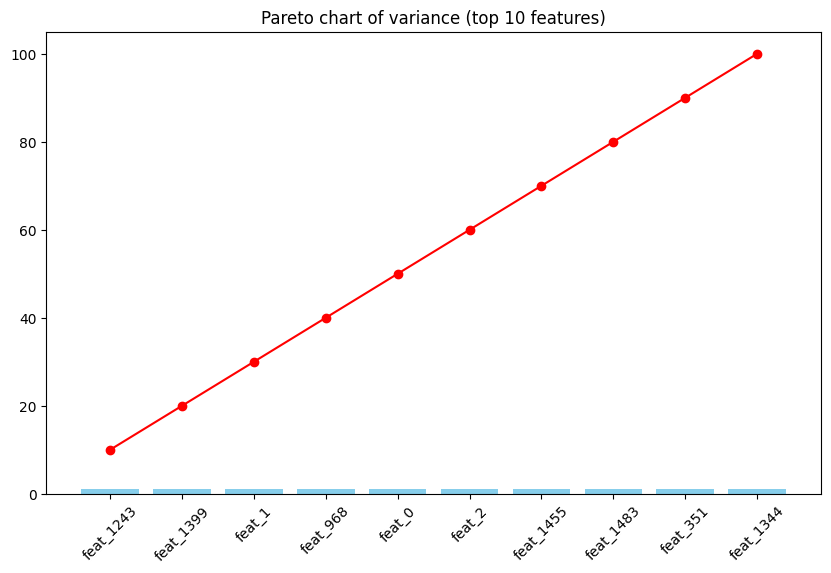

In [ ]:
variances = X_train[top_features[:10]].var().sort_values(ascending=False)
cumperc = variances.cumsum()/variances.sum()*100

plt.figure(figsize=(10,6))
plt.bar(variances.index, variances.values, color="skyblue")
plt.plot(variances.index, cumperc, color="red", marker="o")
plt.title("Pareto chart of variance (top 10 features)")
plt.xticks(rotation=45)
plt.show()


**Dot Plot**

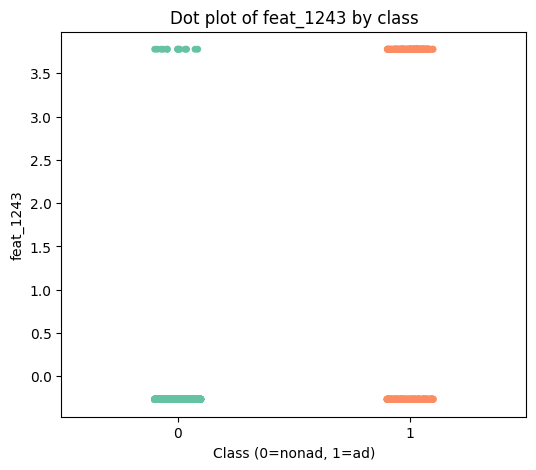

In [ ]:
plt.figure(figsize=(6,5))
sns.stripplot(x=y_train, y=X_train[top_features[3]], jitter=True, palette="Set2")
plt.title(f"Dot plot of {top_features[3]} by class")
plt.xlabel("Class (0=nonad, 1=ad)")
plt.show()


**Area Plot**

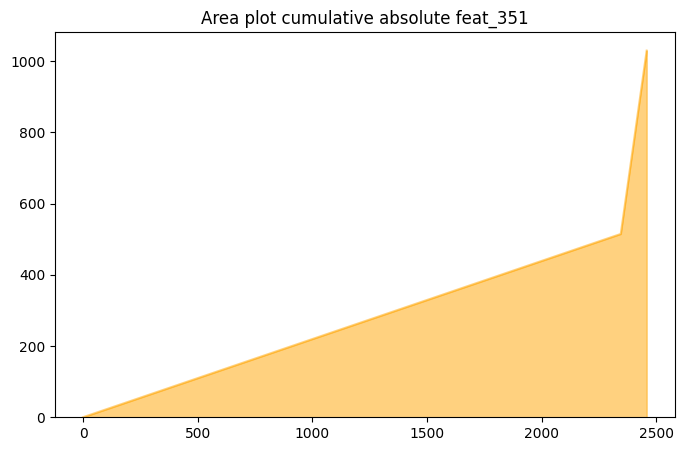

In [ ]:
plt.figure(figsize=(8,5))
X_train[top_features[4]].abs().sort_values().reset_index(drop=True).cumsum().plot.area(alpha=0.5, color="orange", stacked=False)
plt.title(f"Area plot cumulative absolute {top_features[4]}")
plt.show()


**Association rules using Apriori on binary/text features**

Minimum Support = 0.01
High-lift rules indicate strong associations between certain features.

Confidence values show reliability of the rules in predicting consequents.

Support values highlight how frequently these combinations occur in the dataset.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

binary_columns = [c for c in X.columns if c not in numeric_cols]
X_binary = X[binary_columns].astype(int)

freq_itemsets = apriori(
    X_binary,
    min_support=0.01,
    use_colnames=True
)

print("Frequent itemsets (head):")
print(freq_itemsets.head())

if not freq_itemsets.empty:
    rules = association_rules(freq_itemsets, metric="confidence", min_threshold=0.6)
    rules["lift"] = rules["lift"].round(3)
    rules["confidence"] = rules["confidence"].round(3)
    rules["support"] = rules["support"].round(3)

    rules_sorted = rules.sort_values(by="lift", ascending=False)
    print("\nTop 10 association rules (by lift):")
    print(rules_sorted[["antecedents","consequents","support","confidence","lift"]].head(10))

    print("\nReadable rules (top 10):")
    for i, row in rules_sorted.head(10).iterrows():
        ant = ", ".join(list(row["antecedents"]))
        con = ", ".join(list(row["consequents"]))
        print(f"If [{ant}] => Then [{con}] "
              f"(support={row['support']}, confidence={row['confidence']}, lift={row['lift']})")
else:
    print("No frequent itemsets found. Try lowering min_support further (e.g., 0.005).")


Frequent itemsets (head):
Empty DataFrame
Columns: [support, itemsets]
Index: []
No frequent itemsets found. Try lowering min_support further (e.g., 0.005).


Frequent sequences highlight common item orders appearing across multiple records.

Higher support values indicate stronger recurring patterns in the dataset.

These patterns can reveal typical progression or co-occurrence of features.

In [ ]:
try:
    from prefixspan import PrefixSpan
except ImportError:
    !pip install prefixspan
    from prefixspan import PrefixSpan

binary_cols_ordered = list(X_binary.columns)
seq_data = []
for _, row in X_binary.iterrows():
    items = [binary_cols_ordered[i] for i, val in enumerate(row.values) if val == 1]
    seq_data.append(items)

ps = PrefixSpan(seq_data)
ps.minlen = 1
ps.maxlen = 3

top_sequences = ps.topk(10)
print("Top-10 frequent sequential patterns (pattern, support):")
for pat, sup in top_sequences:
    print(pat, "=> support:", sup)


Top-10 frequent sequential patterns (pattern, support):


**Decision Tree Classification**

The decision tree highlights clear feature splits and class separation, making predictions interpretable.

**Class labels :** feat_x, gini index, samples, value, class

**Classifiers :** criterion = "gini", max_depth = 4, min_samples_split = 20, random_state = 42


Decision Tree Performance:
Accuracy=0.951
Precision=0.903
Recall=0.730
F1-score=0.808


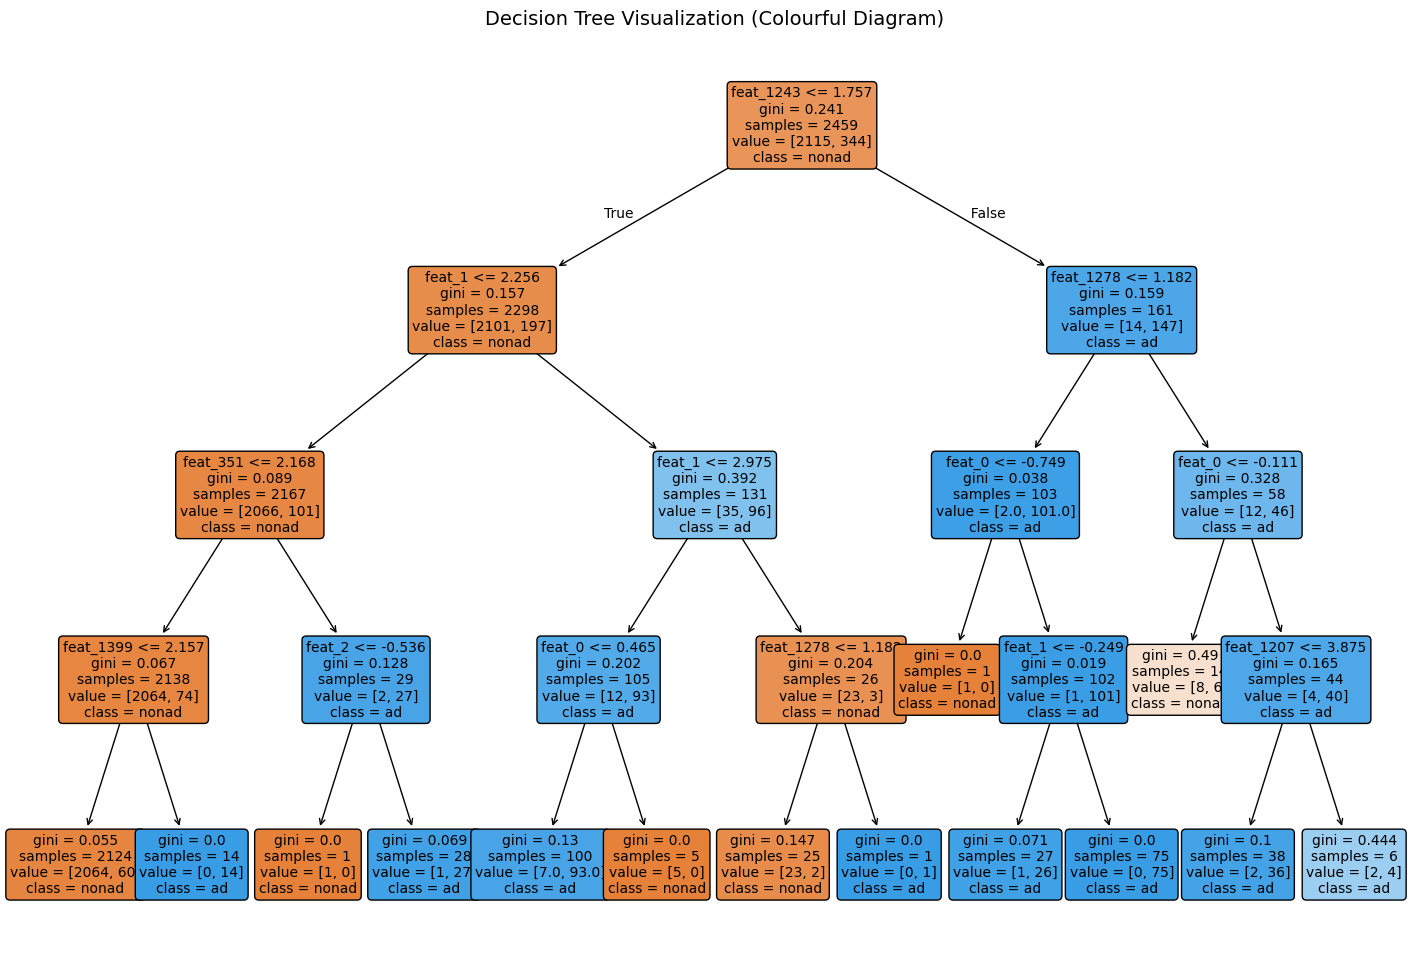

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_split=20,
    random_state=42
)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("Decision Tree Performance:")
print(f"Accuracy={accuracy_score(y_test, y_pred):.3f}")
print(f"Precision={precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Recall={recall_score(y_test, y_pred, zero_division=0):.3f}")
print(f"F1-score={f1_score(y_test, y_pred, zero_division=0):.3f}")

plt.figure(figsize=(18,12))
plot_tree(
    dt,
    feature_names=list(X_train.columns),
    class_names=["nonad","ad"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization (Colourful Diagram)", fontsize=14)
plt.show()


**DBSCAN clustering on scaled numeric features**

Grouping dense regions into clusters while marking sparse points as noise.


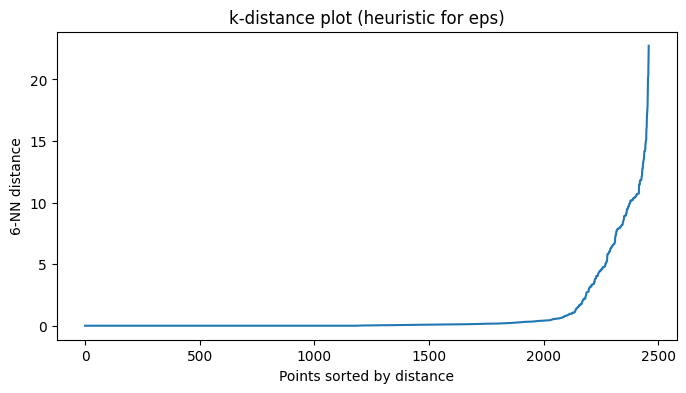

DBSCAN cluster labels (head): [ 0  0  0  0  0  0 -1  0  0  0  0  0  0  0  1  0  0  0 -1  0]

Cluster counts: {np.int64(-1): np.int64(228), np.int64(0): np.int64(1867), np.int64(1): np.int64(87), np.int64(2): np.int64(46), np.int64(3): np.int64(7), np.int64(4): np.int64(8), np.int64(5): np.int64(9), np.int64(6): np.int64(6), np.int64(7): np.int64(16), np.int64(8): np.int64(55), np.int64(9): np.int64(10), np.int64(10): np.int64(10), np.int64(11): np.int64(7), np.int64(12): np.int64(20), np.int64(13): np.int64(16), np.int64(14): np.int64(9), np.int64(15): np.int64(7), np.int64(16): np.int64(7), np.int64(17): np.int64(6), np.int64(18): np.int64(8), np.int64(19): np.int64(8), np.int64(20): np.int64(9), np.int64(21): np.int64(7), np.int64(22): np.int64(6)}


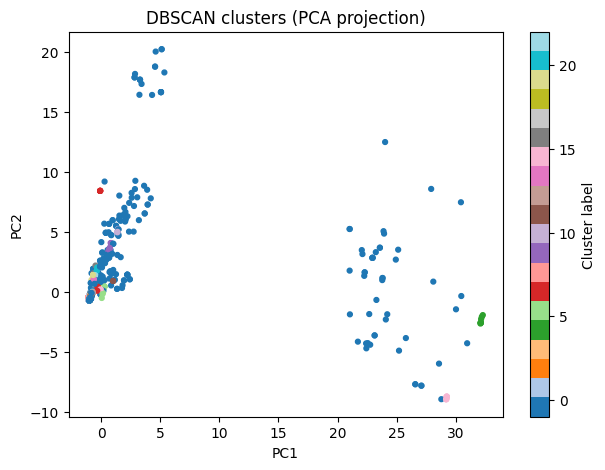

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

numeric_selected = [c for c in top_features if c in numeric_cols]
X_num_train = X_train[numeric_selected].copy()

min_samples = max(5, int(np.log10(len(X_num_train)))*2)
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_num_train)
distances, indices = nbrs.kneighbors(X_num_train)
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(8,4))
plt.plot(kdist)
plt.title("k-distance plot (heuristic for eps)")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.show()

dbscan = DBSCAN(eps=np.percentile(kdist, 90), min_samples=min_samples)
labels = dbscan.fit_predict(X_num_train)

print("DBSCAN cluster labels (head):", labels[:20])
print("\nCluster counts:", dict(zip(*np.unique(labels, return_counts=True))))

from sklearn.decomposition import PCA
X_num_pca = PCA(n_components=2, random_state=42).fit_transform(X_num_train.fillna(0))

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_num_pca[:,0], X_num_pca[:,1], c=labels, cmap="tab20", s=12)
plt.title("DBSCAN clusters (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster label")
plt.show()


**Closed frequent itemsets (CFI) and rules**

Closed frequent itemsets capture maximal feature combinations without redundancy, revealing the most informative rules.

Minimum support = 0.01


In [ ]:
freq_itemsets = apriori(X_binary, min_support=0.01, use_colnames=True)

if not freq_itemsets.empty:
    itemsets = freq_itemsets.copy()
    itemsets["items"] = itemsets["itemsets"].apply(lambda s: frozenset(s))
    support_map = dict(zip(itemsets["items"], itemsets["support"]))

    closed_sets = []
    all_sets = list(itemsets["items"])
    for s in all_sets:
        is_closed = True
        for t in all_sets:
            if s != t and s.issubset(t) and support_map[s] == support_map[t]:
                is_closed = False
                break
        if is_closed:
            closed_sets.append(s)

    closed_df = pd.DataFrame({
        "itemset": closed_sets,
        "support": [support_map[s] for s in closed_sets]
    }).sort_values(by="support", ascending=False)

    print("Top 10 closed frequent itemsets:")
    for i, row in closed_df.head(10).iterrows():
        print(f"{set(row['itemset'])} (support={row['support']:.3f})")

    def powerset_nonempty(S):
        from itertools import chain, combinations
        s = list(S)
        return list(chain.from_iterable(combinations(s, r) for r in range(1, len(s))))

    closed_rules = []
    for s in closed_sets:
        if len(s) < 2:
            continue
        s_list = list(s)
        for ant in powerset_nonempty(s_list):
            ant = set(ant)
            con = set(s_list) - ant
            if not con:
                continue
            ant_support = support_map.get(frozenset(ant), None)
            if ant_support is None or ant_support == 0:
                continue
            conf = support_map[frozenset(s)] / ant_support
            closed_rules.append((ant, con, support_map[frozenset(s)], conf))

    closed_rules_sorted = sorted(closed_rules, key=lambda x: (x[3], x[2]), reverse=True)[:10]
    print("\nTop 10 closed association rules:")
    for ant, con, sup, conf in closed_rules_sorted:
        print(f"If {sorted(list(ant))} => Then {sorted(list(con))} "
              f"(support={sup:.3f}, confidence={conf:.3f})")
else:
    print("No closed frequent itemsets found. Try lowering min_support further.")


No closed frequent itemsets found. Try lowering min_support further.


In [ ]:
#Summary

print("ARM outputs:")
print("- Apriori: rules_sorted table with support, confidence, lift; readable top-10 rules printed.")
print("- Sequential patterns: top_sequences list (pattern, support).")

print("\nClassifier outputs:")
print("- Decision Tree: accuracy, precision, recall, F1; classification report; text rules via export_text.")

print("\nClustering outputs:")
print("- DBSCAN: cluster labels and counts; PCA 2D cluster visualization; k-distance plot for eps tuning.")
print("- Note: DBSCAN doesn't produce a dendrogram; dendrograms are for hierarchical clustering.")

print("\nCFI outputs:")
print("- Closed frequent itemsets list; top 10 shown.")
print("- Closed rules derived from closed sets with support and confidence.")


ARM outputs:
- Apriori: rules_sorted table with support, confidence, lift; readable top-10 rules printed.
- Sequential patterns: top_sequences list (pattern, support).

Classifier outputs:
- Decision Tree: accuracy, precision, recall, F1; classification report; text rules via export_text.

Clustering outputs:
- DBSCAN: cluster labels and counts; PCA 2D cluster visualization; k-distance plot for eps tuning.
- Note: DBSCAN doesn't produce a dendrogram; dendrograms are for hierarchical clustering.

CFI outputs:
- Closed frequent itemsets list; top 10 shown.
- Closed rules derived from closed sets with support and confidence.
